In [1]:
import h5py
import numpy as np
import torch
from torch.utils.data import Dataset
import pandas as pd
import torchvision.models as tv_models
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from torchvision.ops import sigmoid_focal_loss

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [3]:
class ARPESDataset(Dataset):

    def __init__(self, h5_path, labels=None, indices=None, transform=None):

        self.h5_path = h5_path
        self.labels = np.array(labels) if labels is not None else None

        with h5py.File(h5_path, "r", libver="latest", swmr=True) as f:
                data = f["entry/acquisition/data"]
                x = np.arange(data.shape[2])     

        self.indices = np.array(indices) if indices is not None else (
            np.arange(len(self.labels)) if self.labels is not None else None
        )

        if self.indices is None:
            with h5py.File(h5_path, "r", libver="latest", swmr=True) as f:
                data = f["entry/acquisition/data"]
                self.indices = np.arange(data.shape[2])   
                
        self.transform = transform

        self._file = None
        self._data = None

    def _init_file(self):
        if self._file is None:
            self._file = h5py.File(self.h5_path, "r", libver="latest", swmr=True)
            self._data = self._file["entry/acquisition/data"]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):

        self._init_file()

        idx = self.indices[i]
        img = self._data[:, :, idx]

        if self.transform:
            img = self.transform(img)

        if not torch.is_tensor(img):
            img = torch.tensor(img, dtype=torch.float32)

        if img.ndim == 2:
            img = img.unsqueeze(0)
        elif img.ndim == 3 and img.shape[0] != 1:
            # already channel-first tensor
            pass

        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return img, label

In [4]:
class ARPEStestDataset(Dataset):

    def __init__(self, h5_path, labels=None, indices=None, transform=None):

        self.h5_path = h5_path
        self.labels = np.array(labels) if labels is not None else None

        with h5py.File(h5_path, "r", libver="latest", swmr=True) as f:
                data = f["entry/acquisition/data"]
                x = np.arange(data.shape[2])     

        self.indices = np.array(indices) if indices is not None else (
            np.arange(len(self.labels)) if self.labels is not None else None
        )

        if self.indices is None:
            with h5py.File(h5_path, "r", libver="latest", swmr=True) as f:
                data = f["entry/acquisition/data"]
                self.indices = np.arange(data.shape[2])   
                
        self.transform = transform

        self._file = None
        self._data = None

    def _init_file(self):
        if self._file is None:
            self._file = h5py.File(self.h5_path, "r", libver="latest", swmr=True)
            self._data = self._file["entry/acquisition/data"]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):

        self._init_file()

        idx = self.indices[i]
        img = self._data[:, :, idx]

        if self.transform:
            img = self.transform(img)

        if not torch.is_tensor(img):
            img = torch.tensor(img, dtype=torch.float32)

        if img.ndim == 2:
            img = img.unsqueeze(0)
        elif img.ndim == 3 and img.shape[0] != 1:
            # already channel-first tensor
            pass

        return img

In [5]:
class LogNormalize:
    def __call__(self, img):
        img = np.log1p(img.astype(np.float32))
        img = img - img.min()
        img = img / (img.max() + 1e-8)
        return img

In [6]:
import numpy as np
import random

class RandomEnergyWindowCrop:

    def __init__(self, e_min, e_max, window_width_eV):

        self.e_min = e_min
        self.e_max = e_max
        self.window_width_eV = window_width_eV

    def __call__(self, img):

        H, W = img.shape
        #print(f"Original image shape: {img.shape}")
        e_axis = np.linspace(self.e_min, self.e_max, H)

        center = random.uniform(
            self.e_min + self.window_width_eV/2,
            self.e_max - self.window_width_eV/2
        )

        half = self.window_width_eV / 2

        left = np.searchsorted(e_axis, center - half)
        right = np.searchsorted(e_axis, center + half)

        # print(
        #     f"E-range: "
        #     f"{e_axis[left]:.3f} eV -> "
        #     f"{e_axis[right-1]:.3f} eV"
        # )


        return img[left:right,:]

In [7]:
# crop spectra to defined energy window
class EnergyWindowCrop:

    def __init__(self, e_min, e_max):
        self.e_min = e_min
        self.e_max = e_max

    def __call__(self, img):
        H, W = img.shape
        #print(f"Original image shape: {img.shape}")
        e_axis = np.linspace(self.e_min, self.e_max, H)

        window_width_eV = self.e_max - self.e_min
        center = 6.45

        half = window_width_eV / 2

        left = np.searchsorted(e_axis, center - half)
        right = np.searchsorted(e_axis, center + half)

        # print(
        #     f"E-range: "
        #     f"{e_axis[left]:.3f} eV -> "
        #     f"{e_axis[right-1]:.3f} eV"
        # )

        return img[left:right,:]


    

In [8]:
from torchvision import transforms

transform = transforms.Compose([
    #RandomEnergyWindowCrop(5.0, 6.8, window_width_eV=1.3),
    LogNormalize(),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize((288, 216))
])

transform_for_raw = transforms.Compose([
    #EnergyWindowCrop(5.3, 6.6),
    LogNormalize(),
    transforms.ToTensor(),
    transforms.Resize((288, 216))
])

In [9]:
#labels_df = pd.read_csv('/Users/katharinasteinkirchner/Documents/Machine Learning/Classification_table.csv', delimiter=';', usecols=['Symmetrie', 'Resolution'])
labels_df_2 = pd.read_excel('/Users/katharinasteinkirchner/Documents/Machine Learning/Classification_table_Version2.xlsx', usecols=['Resolution'])
#labels_df_2 = pd.read_excel('/Users/atimm/Documents/ML/data/Classification_table_Version2.xlsx', usecols=['Resolution'])

#y = labels_df['Symmetrie'] * labels_df['Resolution']
y = labels_df_2['Resolution']

h5_path = '/Users/katharinasteinkirchner/Documents/Machine Learning/x_y_grid_20260417_105734_020_z000000_snapshot_20260504_103145.h5'
#h5_path = '/users/atimm/Documents/ML/data/x_y_grid_20260417_105734_020_z000000_snapshot_20260504_103145.h5'
with h5py.File(h5_path, "r", libver="latest", swmr=True) as f:
    data = f["entry/acquisition/data"]
    num_samples = data.shape[2]
    print(data.chunks)

(288, 216, 67)


In [10]:
from sklearn.model_selection import train_test_split
import numpy as np
from collections import Counter

indices = np.arange(len(y))

def safe_stratify(labels):
    counts = Counter(labels)
    if len(counts) == 0:
        return None
    return labels if min(counts.values()) >= 2 else None

# train_stratify = safe_stratify(y)
# train_idx, test_idx = train_test_split(
#     indices,
#     test_size=0.15, 
#     random_state=42,
#     stratify=train_stratify
# )

# val_stratify = safe_stratify(y[train_idx])
# train_idx, val_idx = train_test_split(
#     train_idx,
#     test_size=0.1765,
#     random_state=42,
#     stratify=val_stratify
# )


# variante ohne test set, nur train/val split
train_stratify = safe_stratify(y)
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.15, 
    random_state=42,
    stratify=train_stratify
)

In [11]:
train_dataset = ARPESDataset(h5_path, y, train_idx, transform)
val_dataset   = ARPESDataset(h5_path, y, val_idx, transform)
#test_dataset  = ARPESDataset(h5_path, y, test_idx, transform)

full_dataset = ARPESDataset(h5_path, y, transform=transform_for_raw)
full_loader = DataLoader(full_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=False)

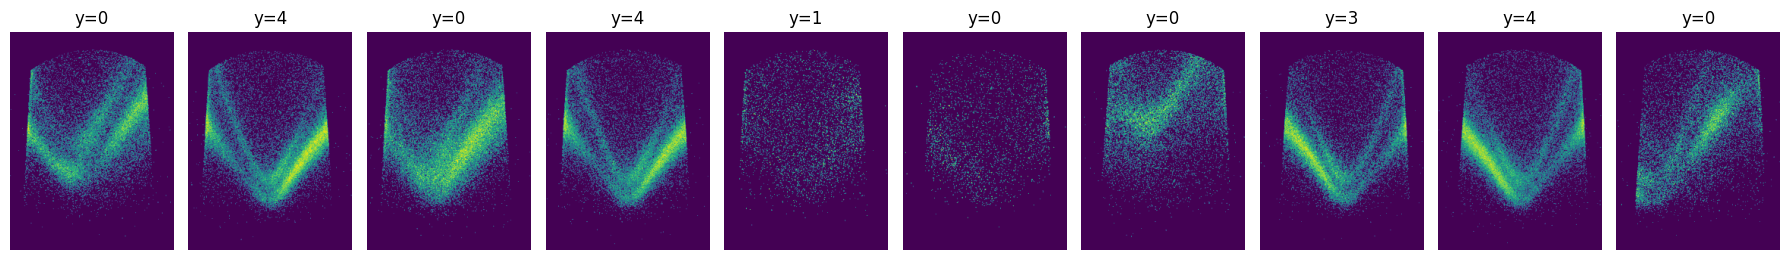

In [12]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

# test_loader = DataLoader(
#     test_dataset,
#     batch_size=32,
#     shuffle=False,
#     num_workers=0
# )

fig, ax = plt.subplots(1, 10, figsize=(18, 3))
for i in range(10):
     img, label = train_dataset[i]
     ax[i].set_title(f"y={label.item()}")
     ax[i].axis("off")
     ax[i].imshow(img.squeeze(0))
plt.tight_layout()
plt.show()

In [13]:
import os
import certifi
from torchvision.models import resnet50, ResNet50_Weights

os.environ["SSL_CERT_FILE"] = certifi.where()

weights = ResNet50_Weights.IMAGENET1K_V1
model = resnet50(weights=weights)

In [14]:
import torch.nn as nn
import torchvision.models as tv_models
import numpy as np

# Load pretrained ResNet-50
model = tv_models.resnet50(pretrained=True)

# Modify first conv layer for grayscale input (1 channel)
model.conv1 = nn.Conv2d(
    1, 64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

# Number of features in final layer
num_ftrs = model.fc.in_features  # 2048 for ResNet-50

# Replace classification head
model.fc = nn.Sequential(
    nn.Dropout(p=0.7),
    nn.Linear(num_ftrs, len(np.unique(y)))
)

# Freeze all parameters
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last 2 residual blocks + classifier
for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True


# Move to device
model = model.to(device)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [15]:
class_counts = np.bincount(y)

weights = len(y) / (len(class_counts) * class_counts)

print(weights)

[0.61072664 4.15294118 1.75621891 0.57119741 1.24734982]


In [16]:
# Optimizer: only params with requires_grad=True
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5, weight_decay=1e-4)
#criterion = nn.CrossEntropyLoss()
#criterion = sigmoid_focal_loss
# LR scheduler (reduce LR on plateau of validation loss)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

boost_factors = {
    3: 1,
    4: 1,
}

weights = torch.tensor(
    weights,
    dtype=torch.float32,
    device=device
)

for cls, factor in boost_factors.items():
    weights[cls] *= factor

print(weights)

criterion = nn.CrossEntropyLoss(
    weight=weights,label_smoothing=0.05
)

tensor([0.6107, 4.1529, 1.7562, 0.5712, 1.2473], device='mps:0')


In [17]:
import matplotlib.pyplot as plt
import numpy as np


def plot_training_metrics(
    train_acc_history,
    val_acc_history,
    precision4_history,
    recall4_history,
    save_path=None
):
    """
    Plot Accuracy, Precision4 und Recall4 über die Epochen.
    """
    
    # Safety check for empty histories
    if not val_acc_history or not precision4_history:
        print("Warning: Training metrics are empty. Did training complete?")
        return

    epochs = np.arange(1, len(val_acc_history) + 1)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy
    ax[0].plot(
        epochs,
        train_acc_history,
        marker='o',
        linewidth=2,
        label='Train Accuracy'
    )

    ax[0].plot(
        epochs,
        val_acc_history,
        marker='s',
        linewidth=2,
        label='Validation Accuracy'
    )

    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Accuracy')
    ax[0].set_title('Accuracy')
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    # Precision / Recall Klasse 4
    ax[1].plot(
        epochs,
        precision4_history,
        marker='o',
        linewidth=2,
        label='Precision (Class 4)'
    )

    ax[1].plot(
        epochs,
        recall4_history,
        marker='s',
        linewidth=2,
        label='Recall (Class 4)'
    )

    best_epoch = np.argmax(precision4_history) + 1

    ax[1].axvline(
        best_epoch,
        color='red',
        linestyle='--',
        alpha=0.7,
        label=f'Best Precision4 (Epoch {best_epoch})'
    )

    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Score')
    ax[1].set_title('Class 4 Metrics')
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


Train samples: 1500, Val samples: 265
Batches per epoch (train): 47, (val): 9

Epoch 1/30


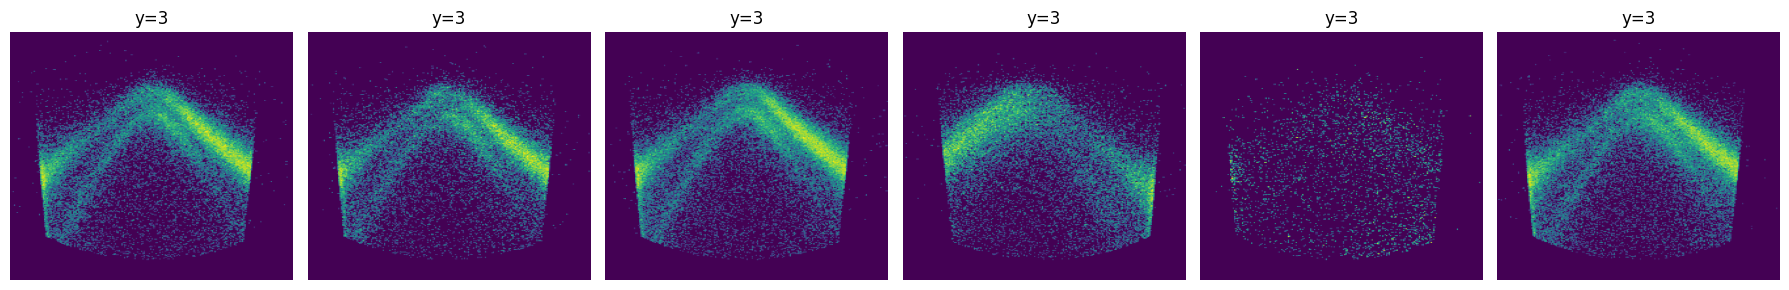

train Loss=1.5890 Acc=0.2327 Precision4=0.2601 Recall4=0.2946 SchedulerLR=1.00e-05


val Loss=1.6110 Acc=0.3132 Precision4=0.0000 Recall4=0.0000 SchedulerLR=1.00e-05

Epoch 2/30


train Loss=1.3300 Acc=0.3840 Precision4=0.3179 Recall4=0.6266 SchedulerLR=1.00e-05


val Loss=1.1891 Acc=0.5132 Precision4=0.3725 Recall4=0.9048 SchedulerLR=1.00e-05

Epoch 3/30


train Loss=1.1827 Acc=0.5620 Precision4=0.4375 Recall4=0.7552 SchedulerLR=1.00e-05


...

val Loss=1.1057 Acc=0.7396 Precision4=0.7273 Recall4=0.7619 SchedulerLR=1.00e-05

Epoch 29/30


train Loss=0.3734 Acc=0.9993 Precision4=0.9959 Recall4=1.0000 SchedulerLR=1.00e-05


val Loss=1.1088 Acc=0.7245 Precision4=0.7674 Recall4=0.7857 SchedulerLR=5.00e-06

Epoch 30/30


train Loss=0.3803 Acc=0.9973 Precision4=1.0000 Recall4=0.9959 SchedulerLR=5.00e-06


val Loss=1.0517 Acc=0.7132 Precision4=0.7174 Recall4=0.7857 SchedulerLR=5.00e-06


In [18]:
# training version - plus precision/recall for class 4 and scheduler

# Debug: Show dataset sizes
#print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
#print(f"Batches per epoch (train): {len(train_loader)}, (val): {len(val_loader)}")

print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}")
print(f"Batches per epoch (train): {len(train_loader)}, (val): {len(val_loader)}")

train_acc_history = []
val_acc_history = []

precision4_history = []
recall4_history = []

epochs_history = []

num_epochs = 30
best_precision4 = 0
visualize_once = True

for epoch in range(num_epochs):

    full_pred = []

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    epoch_start = time.time()
    
    for phase in ['train', 'val']:

        tp4 = 0
        fp4 = 0
        fn4 = 0

        all_preds = []
        all_labels = []
        
        if phase == 'train':

            model.train()
            dataloader = train_loader

            # Visualize only in first epoch
            if visualize_once and epoch == 0:

                for x, z in dataloader:

                    fig, axes = plt.subplots(1, 6, figsize=(18, 3))

                    for i in range(6):

                        img = x[i, 0].cpu().numpy()
                        axes[i].imshow(img, aspect='auto', origin='lower', cmap='viridis')
                        axes[i].set_title(f"y={y[i].item()}")
                        axes[i].axis("off")

                    plt.tight_layout()
                    plt.show()

                    break

                visualize_once = False         

        else:

            model.eval()
            dataloader = val_loader

        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in tqdm(dataloader, desc=f"{phase} epoch {epoch+1}", leave=False):

            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # harte Vorhersage (argmax)

                _, preds = torch.max(outputs, 1)
                pred_is4 = preds == 4
                label_is4 = labels == 4
                full_pred.extend(preds.cpu().numpy())

                # tp4 += (pred_is4 & label_is4).sum().item()
                # fp4 += (pred_is4 & ~label_is4).sum().item()
                # fn4 += (~pred_is4 & label_is4).sum().item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total

        if phase == 'val':
            scheduler.step(precision4)
        precision4 = precision_score(
            all_labels,
            all_preds,
            labels=[4],
            average='macro',
            zero_division=0
        )
        recall4 = recall_score(
            all_labels,
            all_preds,
            labels=[4],
            average='macro',
            zero_division=0
        )

        if phase == 'val' and precision4 > best_precision4:
            best_precision4 = precision4

            torch.save({
                "model_state_dict": model.state_dict(),
                "class_names": np.unique(y).tolist(),
                "transform": "LogNormalize + RandomEnergyWindowCrop",
            }, "arpes_resnet18_best.pt")

        print(
            f"{phase} "
            f"Loss={epoch_loss:.4f} "
            f"Acc={epoch_acc:.4f} "
            f"Precision4={precision4:.4f} "
            f"Recall4={recall4:.4f} "
            f"SchedulerLR={scheduler._last_lr[0]:.2e}"
        )

        # Append metrics to history
        if phase == 'train':
            train_acc_history.append(epoch_acc)
        else:
            val_acc_history.append(epoch_acc)
            precision4_history.append(precision4)
            recall4_history.append(recall4)

        # df = pd.DataFrame({'y_pred': full_pred})
        # df.to_csv('y_preds.csv', index=False)


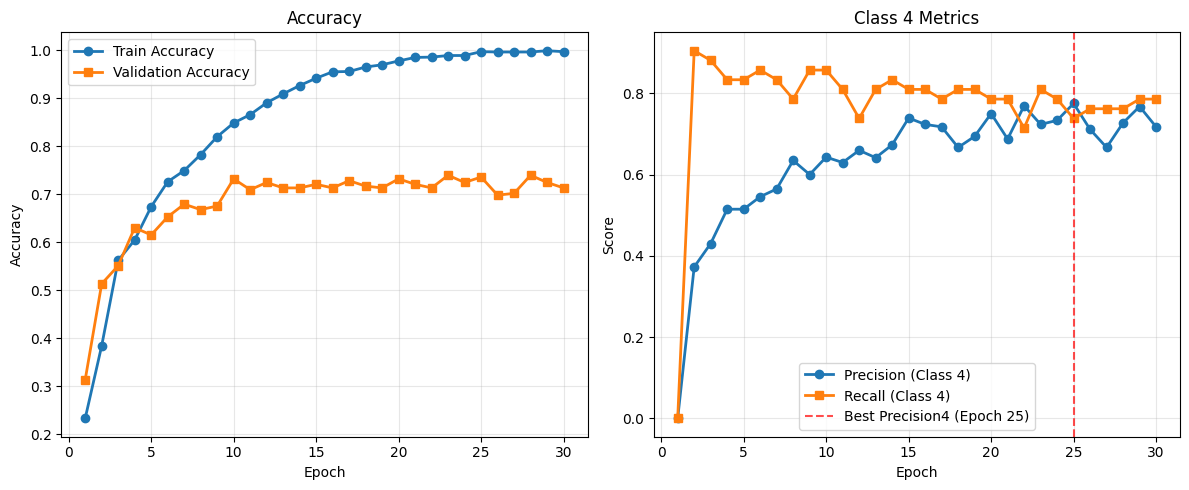

In [19]:
plot_training_metrics(
    train_acc_history,
    val_acc_history,
    precision4_history,
    recall4_history
)

Predicted class distribution:
0 561
1 94
2 203
3 621
4 286
2
Total samples: 1765, Padded samples: 1767


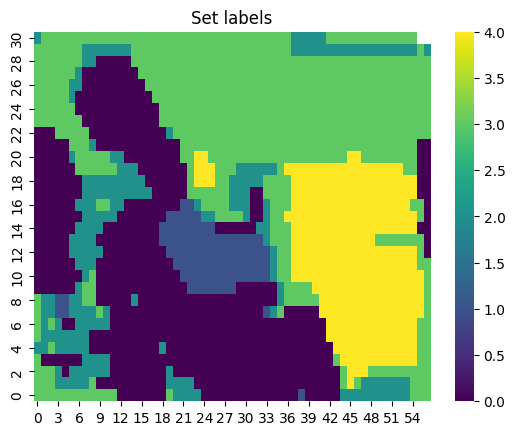

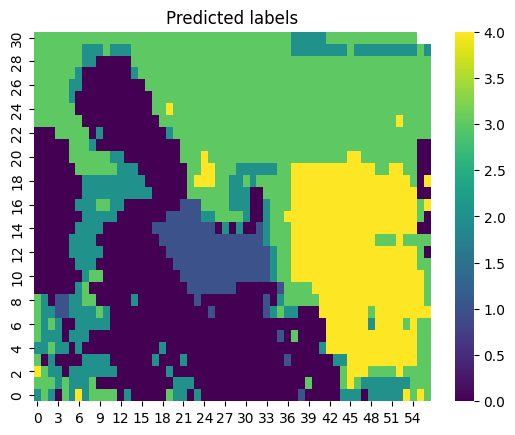

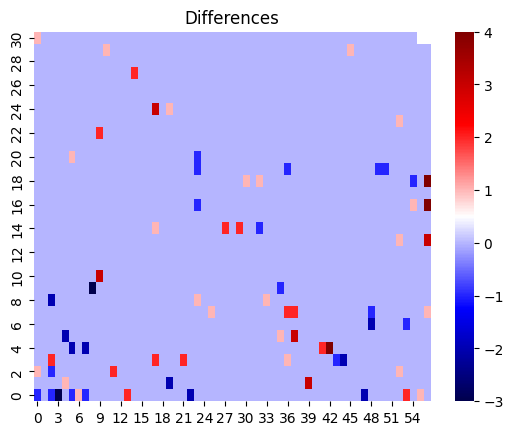

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

x = 57 # number of measurements (ARPES spectra) in x direction on sample

# predictions of model for all samples in dataset
y_pred_full = []
model.eval()
with torch.no_grad():
    for inputs, _ in full_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_pred_full.extend(preds.cpu().numpy())

unique, counts = np.unique(y_pred_full, return_counts=True)

# Debug: Show predicted class distribution
print("Predicted class distribution:")
for u, c in zip(unique, counts):
    print(u, c)

arr = np.asarray(y_pred_full, dtype=float)
pad_len = (-len(arr)) % x
print(pad_len)
print(f"Total samples: {len(arr)}, Padded samples: {len(arr) + pad_len}")
arr_padded = np.pad(arr, (0, pad_len), constant_values=np.nan)
pred_matrix = arr_padded.reshape(-1, x)

true_matrix = np.asarray(y.cpu() if isinstance(y, torch.Tensor) else y, dtype=float)
pad_len_true = (-len(true_matrix)) % x
true_matrix_padded = np.pad(true_matrix, (0, pad_len_true), constant_values=np.nan)
true_matrix = true_matrix_padded.reshape(-1, x)

diff_matrix = pred_matrix - true_matrix

# Ground truth
ax = sns.heatmap(
    true_matrix,
    cmap='viridis',
    cbar=True
)
ax.invert_yaxis()
plt.title("Set labels")
plt.show() 

# Predictions
ax = sns.heatmap(
    pred_matrix,
    cmap='viridis',
    cbar=True
)
ax.invert_yaxis()
plt.title("Predicted labels")
plt.show()

# Differences
ax = sns.heatmap(
    diff_matrix,
    cmap='seismic',
    cbar=True
)
ax.invert_yaxis()
plt.title("Differences")
plt.show()

(288, 216, 67)
Predicted class distribution:
0 81
1 2
2 305
4 908
0
Total samples: 1296, Padded samples: 1296


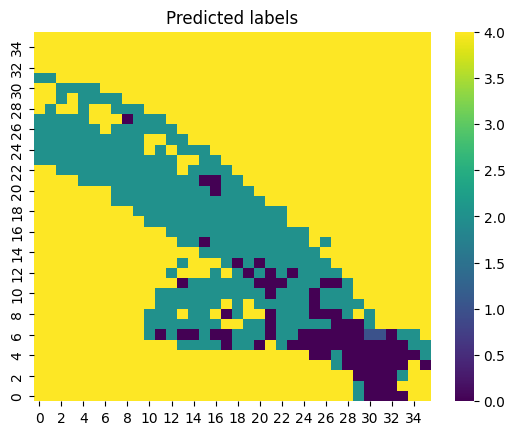

In [22]:
#h5_path_2 = "/Users/atimm/Documents/ML/data/Pos_map_20260526_161920_020_z000000_snapshot_20260526_174221_snapshot_20260616_135309.h5"
#h5_path_2 = "/Users/atimm/Documents/ML/data/Pos_map_20260526_161920_020_z000000_snapshot_20260526_174221_snapshot_20260616_135747.h5"
h5_path_2 = "/Users/katharinasteinkirchner/Documents/Machine Learning/Pos_map_20260526_161920_020_z000000_snapshot_20260526_174221_snapshot_20260616_135747.h5"

with h5py.File(h5_path_2, "r", libver="latest", swmr=True) as f:
    data = f["entry/acquisition/data"]
    num_samples = data.shape[2]
    print(data.chunks)

full_dataset_2 = ARPEStestDataset(h5_path_2, transform=transform_for_raw)
full_loader_2 = DataLoader(full_dataset_2, batch_size=64, shuffle=False, num_workers=0, pin_memory=False)


x = 36 # number of measurements (ARPES spectra) in x direction on sample

# predictions of model for all samples in dataset
y_pred_full = []
model.eval()
with torch.no_grad():
    for inputs in full_loader_2:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_pred_full.extend(preds.cpu().numpy())

unique, counts = np.unique(y_pred_full, return_counts=True)

# Debug: Show predicted class distribution
print("Predicted class distribution:")
for u, c in zip(unique, counts):
    print(u, c)

arr = np.asarray(y_pred_full, dtype=float)
pad_len = (-len(arr)) % x
print(pad_len)
print(f"Total samples: {len(arr)}, Padded samples: {len(arr) + pad_len}")
arr_padded = np.pad(arr, (0, pad_len), constant_values=np.nan)
pred_matrix = arr_padded.reshape(-1, x)


# Predictions
ax = sns.heatmap(
    pred_matrix,
    cmap='viridis',
    cbar=True
)
ax.invert_yaxis()
plt.title("Predicted labels")
plt.show()
